# DicomStructureFile Relations

This notebook is used for prototyping and testing the `DicomStructureFile` class, which is responsible for handling DICOM RT Structure files in medical imaging applications.



## 1. Import Required Libraries

First, let's import the necessary libraries including our custom DicomStructureFile class.

In [1]:
# Import required libraries
from typing import List, Tuple
#import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shapely

# Add the src directory to the Python path
#sys.path.append('src')

# Import our custom DicomStructureFile class
from dicom import DicomStructureFile

# Import related classes
from types_and_classes import SliceIndexType
from contours import ContourPoints
from structure_set import StructureSet
from relations import RelationshipType

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%matplotlib inline

## Demonstrate errors in contours produced by rounding

In [3]:
def points_to_polygon(points: List[Tuple[float, float]]) -> shapely.Polygon:
    '''The points_to_polygon function without validation testing'''
    if not points:
        return shapely.Polygon()
    polygon = shapely.Polygon(points)
    return polygon


# Define the path to the test DICOM file
tests_dir = Path.cwd() / r'Tests'
tests_dir = tests_dir.resolve()
test_file_name = 'RS.GJS_Struct_Tests.BRBL BH.dcm'

print(f"=== Loading DICOM file ===: {test_file_name}")
dicom_file = DicomStructureFile(
    top_dir=tests_dir,
    file_name=test_file_name
)
filtered_contours = dicom_file.filter_exclusions()

dicom_file.structure_names
slice_data = dicom_file.contour_points
contour_table = pd.DataFrame(slice_data)

structure_names_dict = dicom_file.structure_names
structure_names = pd.Series(structure_names_dict, name='StructureName')
structure_names.index.name = 'ROI'
contour_table = contour_table.join(structure_names, on='ROI', how='left')

# Round contour points
dicom_file.round_contour_points()

# Create polygons and calculate areas
contour_table['Polygon'] = contour_table['Points'].apply(points_to_polygon)
contour_table['Area'] = contour_table['Polygon'].apply(lambda poly: poly.area)

# Identify invalid contours
contour_table['IsValid'] = contour_table['Polygon'].apply(shapely.is_valid_reason)
valid_contours = contour_table.IsValid.str.contains('Valid')
selected_columns = ['StructureName', 'ROI', 'Slice', 'IsValid', 'Points']
invalid_contours = contour_table.loc[~valid_contours,selected_columns]
invalid_contours.sort_values(by=['IsValid', 'StructureName'], inplace=True)
print('\nContour Errors:')
print(invalid_contours[['StructureName', 'Slice', 'IsValid']])

print(invalid_contours[invalid_contours.Slice==0.0].Points.tolist())

INFO:dicom:Successfully loaded DICOM dataset from RS.GJS_Struct_Tests.BRBL BH.dcm


=== Loading DICOM file ===: RS.GJS_Struct_Tests.BRBL BH.dcm


INFO:dicom:Extracted 626 contours from 10 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.GJS_Struct_Tests.BRBL BH.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:dicom:Filtered 0 contours from 1 excluded ROIs. Remaining: 626 contours from 9 ROIs
INFO:dicom:Rounded 626 contours to resolution of 0.1 cm/pixel



Contour Errors:
Empty DataFrame
Columns: [StructureName, Slice, IsValid]
Index: []
[]


# Incorrect relations?


In [4]:
test_file_name = 'RS.GJS_Struct_Tests.BRBL BH.dcm'

print(f"=== Loading DICOM file ===: {test_file_name}")
dicom_file = DicomStructureFile(
    top_dir=tests_dir,
    file_name=test_file_name
)
print(f"Successfully loaded: {dicom_file}")
print("=== Creating StructureSet from DicomStructureFile ===")
structure_set = StructureSet(dicom_structure_file=dicom_file)
print("\n=== Calculating Structure Relationships ===")
structure_set.calculate_relationships()
print("\n=== Structure Relationship Summary Table ===")
symbol_map = {RelationshipType.UNKNOWN: '?',
              RelationshipType.DISJOINT: '',
              RelationshipType.EQUALS: '='
        }
relationship_summary = structure_set.relationship_summary(symbol_map=symbol_map)
#print(relationship_summary)
relationship_summary

INFO:dicom:Successfully loaded DICOM dataset from RS.GJS_Struct_Tests.BRBL BH.dcm


=== Loading DICOM file ===: RS.GJS_Struct_Tests.BRBL BH.dcm


INFO:dicom:Extracted 626 contours from 10 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.GJS_Struct_Tests.BRBL BH.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:structure_set:Building StructureSet from 626 contour points


Successfully loaded: DICOM RT Structure: BRBL BH for patient GJS_Struct_Tests
=== Creating StructureSet from DicomStructureFile ===

=== Calculating Structure Relationships ===


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)



=== Structure Relationship Summary Table ===


Structure_B,BODY,Cavity,CTV Cavity,eval PTV,PTV Cavity,Heart,Lung B,Lung L,Lung R
Structure_A,,,,,,,,,
BODY,=,Contains,Contains,Contains,Overlaps,Contains,Partition,Partition,Partition
Cavity,?,=,Overlaps,Overlaps,Overlaps,,,,
CTV Cavity,?,Overlaps,=,Overlaps,Overlaps,,,,
eval PTV,?,Overlaps,Overlaps,=,Overlaps,,,,
PTV Cavity,Overlaps,Overlaps,Overlaps,Overlaps,=,,,,
Heart,?,,,,,=,Borders,Borders,Borders
Lung B,?,,,,,Borders,=,Overlaps,Partition
Lung L,?,,,,,Borders,Overlaps,=,
Lung R,?,,,,,Borders,?,,=


In [5]:
structure_names

ROI
14    PTV Cavity
9           BODY
20        Lung R
13      eval PTV
12    CTV Cavity
11        Cavity
19        Lung L
18        Lung B
17         Heart
Name: StructureName, dtype: object

In [6]:

contour_list = pd.DataFrame(dicom_file.contour_points)
structure_names = pd.Series(dicom_file.structure_names, name='StructureName')
contours = contour_list.join(structure_names, on='ROI', how='left')

contours = contours.groupby(['StructureName', 'ROI', 'Slice']).count()
slice_table = contours.unstack(level=['StructureName', 'ROI'])
slice_table.columns = slice_table.columns.droplevel(0)
slice_table.loc[1.0,:].to_dict()

{('BODY', 9): 1.0,
 ('CTV Cavity', 12): 1.0,
 ('Cavity', 11): 1.0,
 ('Heart', 17): nan,
 ('Lung B', 18): 2.0,
 ('Lung L', 19): 1.0,
 ('Lung R', 20): 1.0,
 ('PTV Cavity', 14): 1.0,
 ('eval PTV', 13): 1.0}

In [7]:
# Get slice information from the structure set
slice_indexes = structure_set.slice_sequence.slices
print(f"Available slices: {len(slice_indexes)}")
print(f"Slice range: {min(slice_indexes):.2f} to {max(slice_indexes):.2f}")

# Find the central slice
central_slice = slice_indexes[len(slice_indexes) // 2]
print(f"Central slice index: {central_slice}")

Available slices: 127
Slice range: -13.88 to 14.12
Central slice index: -0.25


## Example: Plot Structure Comparison on a Slice

Use `plot_roi_slice` to visualize the relationship between two structures on a specific slice.

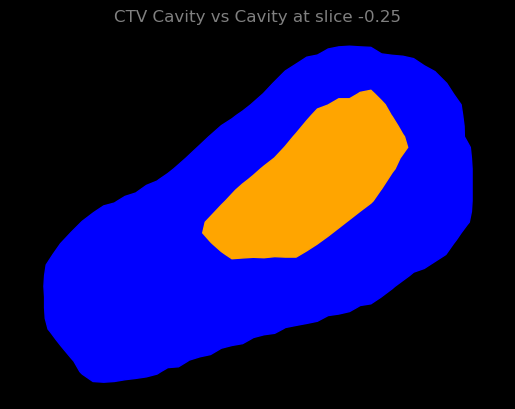

In [8]:
from debug_tools import plot_roi_slice

# Plot 'CTV Cavity' and 'Cavity' structures at the central slice
# Blue = only in CTV Cavity, Green = only in Cavity, Orange = overlap
ax = plot_roi_slice(structure_set,
               slice_index=central_slice,
               structure_names=['CTV Cavity', 'Cavity'])

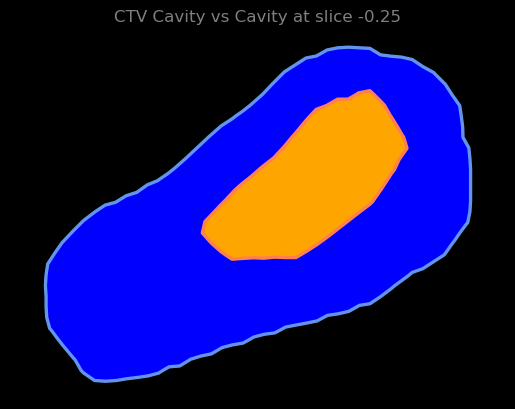

In [10]:
from debug_tools import plot_roi_slice

# Plot 'CTV Cavity' and 'Cavity' structures at the central slice
# Blue = only in CTV Cavity, Green = only in Cavity, Orange = overlap
ax = plot_roi_slice(structure_set, slice_index=central_slice,
                    structure_names=['CTV Cavity', 'Cavity'], tolerance=0.1)

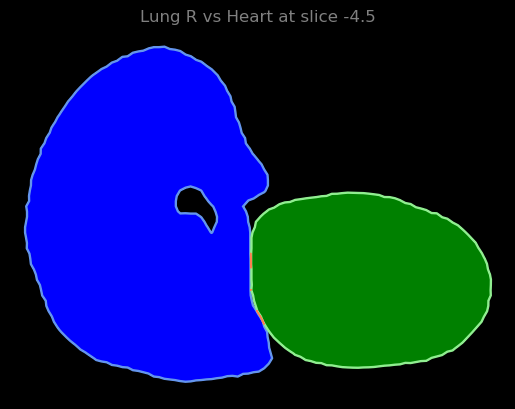

In [12]:
from debug_tools import plot_roi_slice

# Plot 'CTV Cavity' and 'Cavity' structures at the central slice
# Blue = only in CTV Cavity, Green = only in Cavity, Orange = overlap
ax = plot_roi_slice(structure_set, slice_index=-4.5,
                    structure_names=['Lung R', 'Heart'], tolerance=0.1)